# European option prices and Greeks in general rough Bergomi models

## Quick summary of the method

In this notebook, we illustrate how to price European options and compute Greeks in one-dimensional asset-price models of the form
$$
X_t^{t,x}=x, 
\qquad 
\mathrm{d}X_s^{t,x}
=
f(s,X_s^{t,x})v_s\,\mathrm{d}W_s
+
g(s,X_s^{t,x})v_s\,\mathrm{d}B_s,
$$
where $W$ and $B$ are two independent Brownian motions, the volatility process $(v_t)_{t\geq 0}$ is $\mathcal{F}^W$-adapted, and $f,g$ are general leverage functions, typically obtained by calibration and here treated as given.

In the examples below, we focus on rough Bergomi-type volatility models. More precisely, following the parametrization of Bayer et al., we take
$$
V_t
=
\xi_0
\mathcal{E}
\left(
\eta
\int_0^t (t-s)^{H-\frac12}\,\mathrm{d}W_s
\right),
\qquad
\xi_0 = 0.235^2,
\qquad
\eta = 1.9,
\qquad
H = 0.07,
$$
and use $v_t=\sqrt{V_t}$ in the asset-price dynamics. The method, however, does not rely on this particular volatility specification and can be used with other volatility models.

We numerically compute pricing curves
$$
x \mapsto \mathbb{E}\left[\phi(X_T^{0,x})\right],
$$
as well as the corresponding Delta and Gamma curves
$$
x \mapsto \partial_x \mathbb{E}\left[\phi(X_T^{0,x})\right],
\qquad
x \mapsto \partial_{xx}^2 \mathbb{E}\left[\phi(X_T^{0,x})\right],
$$
where the user can specify the input data $(\phi,f,g)$.

The numerical method is based on the partial Monte Carlo approach introduced in https://doi.org/10.1111/mafi.12458. The key idea is to condition on the Brownian motion driving the volatility. Conditional on this Brownian motion, the remaining price dynamics can be represented pathwise, and the corresponding conditional prices are characterized by a rough PDE. More precisely, leaving the theoretical details to https://doi.org/10.1111/mafi.12458, one has
$$
\mathbb{E}\left[\phi(X_T^{t,x})\right]
=
\mathbb{E}
\left[
\mathbb{E}\left[\phi(X_T^{t,x})\mid \mathcal{F}^W\right]
\right]
=
\mathbb{E}\left[u(t,x,\omega)\right],
$$
where, for each fixed volatility path, $u(t,x,\omega)$ solves a backward rough PDE of the form
$$ u(T,x, \omega) \equiv  \phi(x), \qquad 
-\mathrm{d}_t u(t,x,\omega)
=
L_t[u](t,x,\omega)\,v_t^2(\omega)\,\mathrm{d}t
+
\Gamma_t[u](t,x,\omega)\,\mathrm{d}\mathbf{I}_t(\omega),
$$
for suitable differential operators $L$ and $\Gamma$. Here the driving rough path is given by
$$
\mathbf{I}_t
=
(I_t,\mathbb{I}_t)
=
\left(
\int_0^t v_s(\omega)\,\mathrm{d}W_s,
\int_0^t \int_0^s v_s(\omega)v_r(\omega)\,\mathrm{d}W_r\,\mathrm{d}W_s
\right).
$$

Given samples of the rough path $\mathbf{I}(\omega)$, constructed from the simulated volatility and its driving Brownian motion, we solve the RPDE sample by sample using finite-difference schemes. We then average the sample-wise conditional solutions to obtain the final option price. The PDE solver is implemented in `RPDE_solver.py`; the goal of this notebook is to demonstrate how to use it.


# Step 1: Import functions

First, we import the PDE solver and some helper functions, as well as the rough Bergomi simulation code, which directly produces the required samples of the rough path $\mathbf{I}$ introduced above. We emphasize again that, if a similar sampler is available for a different volatility model, this step can be replaced and the remainder of the workflow works in the same way.

In [120]:
import numpy as np
import matplotlib.pyplot as plt

from RPDE_solver import (
    SpaceTimeGrid,
    OneDimensionalRoughPath,
    interpolate_paths_to_grid,
    solve_rpde_paper_scheme_1d,
    SimpleAsymptoticBoundary,

)
from Greeks import FiniteDifferenceGreeks

from rBergomi_simulation import SimulationofrBergomi 

## Step 2: rough Bergomi samples

In [121]:
M = 5000  #Number of samples along which the PDE is solved-
N_sim = 5000          # number of grid-points for the simlutation of rBergomi data
J_pde = 120           # time grid for PDE
N_space = 90          # space grid for PDE

T = 1.0 #terminal time
rho = -0.4 #correlation of the price and volatility
a = 0.01 #left boundary value for the PDE
b = 10.0 #right boundary value for the PDE
K = 5.0  #Strike of the option
S0 = 5.0 #initial value of the price

r = 0.0 #no interest-rate supported currently

#rough Bergomi parameters:
H = 0.07       # replace by your old parameter
xi = 0.235**2     # replace by your old parameter
eta = 1.9     


def payoff(x):
    return np.maximum(K - x, 0.0)

X, V, I_fine, QV_fine, dI_fine, dQV_fine, dW1, dW2, dB = SimulationofrBergomi(
    M=M,
    N=N_sim,
    T=T,
    phi=payoff,
    rho=rho,
    K=K,
    X0=S0,
    H=H,
    xi=xi,
    eta=eta,
    r=r,
)

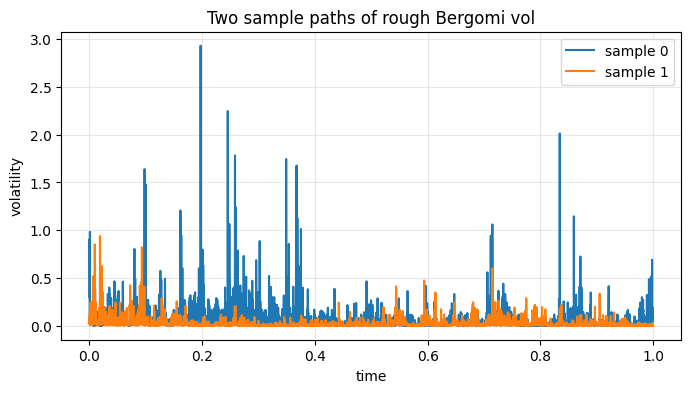

In [122]:
import numpy as np
import matplotlib.pyplot as plt

# time grid corresponding to V
t_vol = np.linspace(0.0, T, V.shape[1])

# choose 3 sample indices
sample_ids = [0, 1]

fig, ax = plt.subplots(figsize=(8, 4))

for m in sample_ids:
    ax.plot(t_vol, V[m], label=f"sample {m}")

ax.set_xlabel("time")
ax.set_ylabel("volatility")
ax.set_title("Two sample paths of rough Bergomi vol")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

In [123]:
#interpolate paths and build the rough path
t_sim = np.linspace(0.0, T, N_sim + 1)
t_pde = np.linspace(0.0, T, J_pde + 1)
x_grid = np.linspace(a, b, N_space + 1)

grid = SpaceTimeGrid(t=t_pde, x=x_grid)

I_pde = interpolate_paths_to_grid(
    source_t=t_sim,
    values=I_fine,
    target_t=t_pde,
)

QV_pde = interpolate_paths_to_grid(
    source_t=t_sim,
    values=QV_fine,
    target_t=t_pde,
)
rough_path = OneDimensionalRoughPath(
    Y=I_pde,
    qv=QV_pde,
)

# Step 3: Specification of the model $(\phi,f,g)$

We use put-option payoffs here, and consider SABR type of dynamics: $$f(t,x)=\rho x^\beta, \qquad g(t,x)=\sqrt{1-\rho^2} x^\beta $$ for some $\beta \in (0,1]$. Note for $\beta=1$ this corresponds to the standard rough Bergomi model.

In [124]:
def payoff(x):
    return np.maximum(K-x, 0.0)

def f(t, x):
    return rho * x**beta

def f_x(t, x):
    return rho * beta * x**(beta - 1.0)

def g(t, x):
    return np.sqrt(1.0 - rho**2) * x**beta

# Step 4: Solving the RPDEs and average

In [125]:
#we consider Dirichlet boundaries, but also more sophisticated possibilities are available.
boundary = SimpleAsymptoticBoundary(
    payoff=payoff,
)

boundary_left, boundary_right = boundary.compute(
    grid=grid,
    rough_path=rough_path,
)

In [126]:
U = solve_rpde_paper_scheme_1d(
    f=f,
    g=g,
    f_x=f_x,
    payoff=payoff,
    grid=grid,
    rough_path=rough_path,
    boundary_left=boundary_left,
    boundary_right=boundary_right,
)

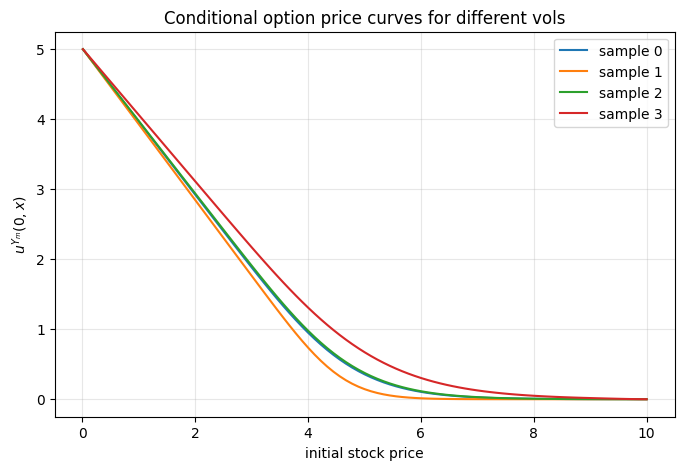

In [127]:
import matplotlib.pyplot as plt
import numpy as np

# choose 4 sample indices
sample_ids = [0, 1, 2, 3]

fig, ax = plt.subplots(figsize=(8, 5))

for m in sample_ids:
    ax.plot(x_grid, U[m, 0, :], label=f"sample {m}")

ax.set_xlabel("initial stock price")
ax.set_ylabel(r"$u^{Y_m}(0,x)$")
ax.set_title("Conditional option price curves for different vols")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

Next we average over all samples to get the true price

In [128]:
sample_price_curves = U[:, 0, :]
price_curve = np.mean(sample_price_curves, axis=0)
price_std = np.std(sample_price_curves, axis=0) / np.sqrt(U.shape[0])

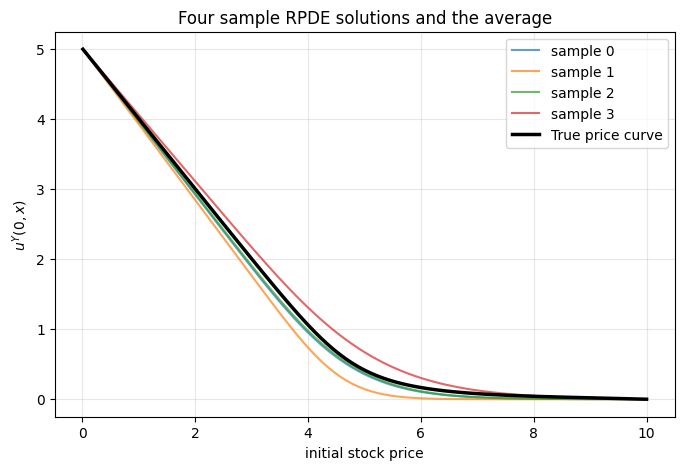

In [129]:
import matplotlib.pyplot as plt
import numpy as np

# choose 4 sample indices
sample_ids = [0, 1, 2, 3]

# average over the outer samples
mean_curve = np.mean(U[:, 0, :], axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

for m in sample_ids:
    ax.plot(x_grid, U[m, 0, :], alpha=0.7, label=f"sample {m}")

ax.plot(x_grid, mean_curve, "k-", linewidth=2.5, label="True price curve")

ax.set_xlabel("initial stock price")
ax.set_ylabel(r"$u^{Y}(0,x)$")
ax.set_title("Four sample RPDE solutions and the average")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

# Step 5: Compute the Greeks $\Delta$ and $\Gamma$

In [130]:
greeks = FiniteDifferenceGreeks(solution=U, grid=grid)

eps = 0.05 #finite difference approximation steps for greeks
x_eval = np.linspace(a + eps, b - eps, 100)

price = greeks.price()
delta = greeks.delta()
gamma = greeks.gamma()

delta_eps = greeks.delta_bumped(x_eval, bump=eps)
gamma_eps = greeks.gamma_bumped(x_eval, bump=eps)

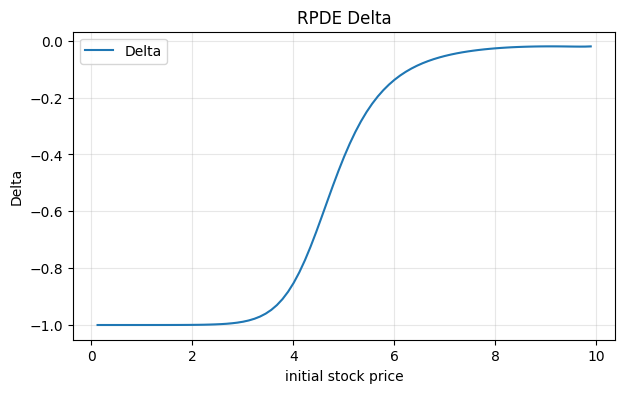

In [131]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(delta.x, delta.mean, label="Delta")
ax.fill_between(
    delta.x,
    delta.mean - 1.96 * delta.stderr,
    delta.mean + 1.96 * delta.stderr,
    alpha=0.2,
)

ax.set_xlabel("initial stock price")
ax.set_ylabel("Delta")
ax.set_title("RPDE Delta")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

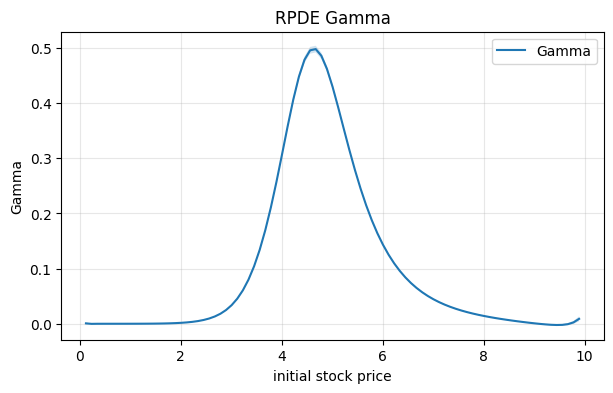

In [132]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(gamma.x, gamma.mean, label="Gamma")
ax.fill_between(
    gamma.x,
    gamma.mean - 1.96 * gamma.stderr,
    gamma.mean + 1.96 * gamma.stderr,
    alpha=0.2,
)

ax.set_xlabel("initial stock price")
ax.set_ylabel("Gamma")
ax.set_title("RPDE Gamma")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()